<a href="https://colab.research.google.com/github/sergiodanier1/acuacode/blob/main/IA_pokemon_generativa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Conectar con el drive



In [21]:
import os
from google.colab import drive

# Ahora montamos Drive
drive.mount('/content/drive')

rm: cannot remove '/content/drive/MyDrive': Operation canceled
rm: cannot remove '/content/drive/.shortcut-targets-by-id': Operation canceled
rm: cannot remove '/content/drive/.Trash-0': Directory not empty
rm: cannot remove '/content/drive/.Encrypted/MyDrive': Operation canceled
rm: cannot remove '/content/drive/.Encrypted/.shortcut-targets-by-id': Operation canceled
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Dependencias

In [22]:
!pip install tqdm matplotlib pillow pandas numpy torch torchvision -q
!pip install -q tensorflow pandas scikit-learn

2. Cargar librerías

In [23]:
import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

3 Rutas

In [27]:
BASE_DIR = "/content/drive/MyDrive/mi_proyecto_pokemon"

CARPETA_IMAGENES = os.path.join(BASE_DIR, "datos_procesados")

ARCHIVO_CSV = os.path.join(
    BASE_DIR,
    "metadata",
    "etiquetas_pokemon.csv"
)

4 Leer el CSV

In [30]:
metadata = pd.read_csv(ARCHIVO_CSV)
metadata.head()

,nombre_archivo,postura_bipedo,postura_cuadrupedo,postura_serpentiforme,postura_volador,ojos_circulares,ojos_rasgados,sin_ojos,delantera_brazo,delantera_pata,delantera_ala,sin_delantera,trasera_pata_animal,trasera_pata_ave,sin_trasera,cola_larga_flexible,cola_maza,sin_cola,nivel_evolutivo
0,001.npy,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,1
1,002.npy,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,2
2,003.npy,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,3
3,004.npy,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,1
4,005.npy,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,2


5. cargar imagenes

In [31]:
archivos = sorted(glob.glob(os.path.join(CARPETA_IMAGENES,"*.npy")))

imagenes = []

for archivo in archivos:

    img = np.load(archivo)

    img = img.astype(np.float32)

    if img.max()>1:
        img = img/255.0

    imagenes.append(img)

imagenes = np.array(imagenes)

print(imagenes.shape)

(400, 64, 64, 3)


6. División entrenamiento

In [32]:
x_train, x_test = train_test_split(
    imagenes,
    test_size=0.1,
    random_state=42
)

7. Dimensiones

In [33]:
alto = imagenes.shape[1]
ancho = imagenes.shape[2]
canales = imagenes.shape[3]

latent_dim = 128

8. Encoder

In [34]:
encoder_inputs = tf.keras.Input(shape=(alto,ancho,canales))

x = layers.Conv2D(32,3,strides=2,padding="same",activation="relu")(encoder_inputs)
x = layers.Conv2D(64,3,strides=2,padding="same",activation="relu")(x)
x = layers.Conv2D(128,3,strides=2,padding="same",activation="relu")(x)

shape_before = tf.keras.backend.int_shape(x)

x = layers.Flatten()(x)

z = layers.Dense(latent_dim)(x)

encoder = tf.keras.Model(encoder_inputs,z)

encoder.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,141,952 (4.36 MB)

 Trainable params: 1,141,952 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

9. Decoder

In [35]:
decoder_inputs = tf.keras.Input(shape=(latent_dim,))

unidades = int(np.prod(shape_before[1:]))

x = layers.Dense(unidades)(decoder_inputs)

x = layers.Reshape(shape_before[1:])(x)

x = layers.Conv2DTranspose(
    128,
    3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

x = layers.Conv2DTranspose(
    64,
    3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

x = layers.Conv2DTranspose(
    32,
    3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

decoder_outputs = layers.Conv2D(
    canales,
    3,
    padding="same",
    activation="sigmoid"
)(x)

decoder = tf.keras.Model(decoder_inputs, decoder_outputs)

10. Autoencoder

In [36]:
inputs = tf.keras.Input(shape=(alto,ancho,canales))

latent = encoder(inputs)

outputs = decoder(latent)

autoencoder = tf.keras.Model(inputs,outputs)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

11. Entrenamiento

In [37]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Carpeta donde se guardarán las imágenes de cada época
CARPETA_RESULTADOS = os.path.join(BASE_DIR, "imagenes_entrenamiento")
os.makedirs(CARPETA_RESULTADOS, exist_ok=True)

class GuardarImagenes(tf.keras.callbacks.Callback):

    def on_epoch_end(self, epoch, logs=None):

        # Generar 9 imágenes aleatorias
        ruido = np.random.normal(size=(9, latent_dim))

        imagenes = decoder.predict(ruido, verbose=0)

        fig, axs = plt.subplots(3, 3, figsize=(6,6))

        for i, ax in enumerate(axs.flat):

            ax.imshow(np.clip(imagenes[i],0,1))
            ax.axis("off")

        plt.tight_layout()

        nombre = os.path.join(
            CARPETA_RESULTADOS,
            f"epoch_{epoch+1:03d}.png"
        )

        plt.savefig(nombre)
        plt.close(fig)

        print(f"\nImagen guardada: {nombre}")

# Entrenamiento
history = autoencoder.fit(

    x_train,
    x_train,

    validation_data=(x_test, x_test),

    epochs=300,

    batch_size=16,

    callbacks=[GuardarImagenes()]
)

Epoch 1/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - loss: 0.6576
Imagen guardada: /content/drive/MyDrive/mi_proyecto_pokemon/imagenes_entrenamiento/epoch_001.png
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 295ms/step - loss: 0.5797 - val_loss: 0.4173
Epoch 2/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - loss: 0.3997
Imagen guardada: /content/drive/MyDrive/mi_proyecto_pokemon/imagenes_entrenamiento/epoch_002.png
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 382ms/step - loss: 0.3933 - val_loss: 0.3807
Epoch 3/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - loss: 0.3890
Imagen guardada: /content/drive/MyDrive/mi_proyecto_pokemon/imagenes_entrenamiento/epoch_003.png
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 303ms/step - loss: 0.3896 - val_loss: 0.3807
Epoch 4/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - loss: 0.3836
Imagen guardada: /content/drive/MyDrive/mi_proyecto_pokemon/imagenes_entrenamiento/epoch_004.png
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 338ms/step - loss: 0.3897 - val_loss: 0.3808
Epoch 5/300
23/23 ━━━━━━━━━━━━━━━━━━━━

12. Guardar modelo

In [38]:
MODELOS = os.path.join(BASE_DIR,"modelos")

os.makedirs(MODELOS,exist_ok=True)

autoencoder.save(
    os.path.join(MODELOS,"pokemon_generator.keras")
)

13. Generar nuevos Pokémon

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


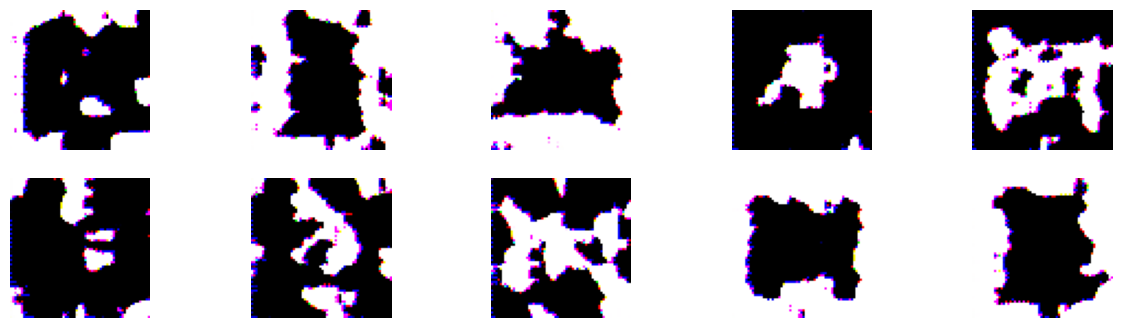

In [39]:
import matplotlib.pyplot as plt

ruido = np.random.normal(
    size=(10,latent_dim)
)

imagenes_generadas = decoder.predict(ruido)

plt.figure(figsize=(15,4))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(imagenes_generadas[i])

    plt.axis("off")

plt.show()

Modelo Gan

In [ ]:
import os, glob, csv
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

# ================= CONFIG =================
BASE_DIR="/content/drive/MyDrive/mi_proyecto_pokemon"
CARPETA_IMAGENES=os.path.join(BASE_DIR,"datos_procesados")
NUM_IMAGENES=400
IMG_SIZE=64
CHANNELS=3
LATENT_DIM=100
EPOCHS=500
BATCH_SIZE=32
LR=2e-4
BETA1=0.5
GUARDAR_CADA=10

OUT=os.path.join(BASE_DIR,"GAN")
IMG_DIR=os.path.join(OUT,"imagenes_entrenamiento2")
MODEL_DIR=os.path.join(OUT,"modelos")
os.makedirs(IMG_DIR,exist_ok=True)
os.makedirs(MODEL_DIR,exist_ok=True)

# ================ DATA ====================
files=sorted(glob.glob(os.path.join(CARPETA_IMAGENES,"*.npy")))
if NUM_IMAGENES:
    files=files[:NUM_IMAGENES]

imgs=[]
for f in files:
    x=np.load(f).astype("float32")
    if x.max()>1: x/=255.
    if x.shape[:2]!=(IMG_SIZE,IMG_SIZE):
        x=tf.image.resize(x,(IMG_SIZE,IMG_SIZE)).numpy()
    imgs.append(x)
imgs=np.array(imgs)
dataset=tf.data.Dataset.from_tensor_slices(imgs).shuffle(len(imgs)).batch(BATCH_SIZE)

# ============== MODELS ====================
def build_generator():
    z=tf.keras.Input((LATENT_DIM,))
    x=layers.Dense(8*8*256,use_bias=False)(z)
    x=layers.BatchNormalization()(x)
    x=layers.LeakyReLU()(x)
    x=layers.Reshape((8,8,256))(x)
    for f in [128,64,32]:
        x=layers.Conv2DTranspose(f,4,2,"same",use_bias=False)(x)
        x=layers.BatchNormalization()(x)
        x=layers.LeakyReLU()(x)
    out=layers.Conv2D(CHANNELS,3,padding="same",activation="sigmoid")(x)
    return tf.keras.Model(z,out)

def build_discriminator():
    i=tf.keras.Input((IMG_SIZE,IMG_SIZE,CHANNELS))
    x=i
    for f in [32,64,128,256]:
        x=layers.Conv2D(f,4,2,"same")(x)
        x=layers.LeakyReLU(0.2)(x)
        x=layers.Dropout(.3)(x)
    x=layers.Flatten()(x)
    out=layers.Dense(1)(x)
    return tf.keras.Model(i,out)

G=build_generator()
D=build_discriminator()

bce=tf.keras.losses.BinaryCrossentropy(from_logits=True)
g_opt=tf.keras.optimizers.Adam(LR,beta_1=BETA1)
d_opt=tf.keras.optimizers.Adam(LR,beta_1=BETA1)

@tf.function
def train_step(real):
    noise=tf.random.normal([tf.shape(real)[0],LATENT_DIM])
    with tf.GradientTape() as gt, tf.GradientTape() as dt:
        fake=G(noise,training=True)
        r=D(real,training=True)
        f=D(fake,training=True)
        g_loss=bce(tf.ones_like(f),f)
        d_loss=bce(tf.ones_like(r),r)+bce(tf.zeros_like(f),f)
    g_opt.apply_gradients(zip(gt.gradient(g_loss,G.trainable_variables),G.trainable_variables))
    d_opt.apply_gradients(zip(dt.gradient(d_loss,D.trainable_variables),D.trainable_variables))
    return g_loss,d_loss

fixed=tf.random.normal([9,LATENT_DIM])
hist=os.path.join(OUT,"historial.csv")
with open(hist,"w",newline="") as f:
    w=csv.writer(f); w.writerow(["epoch","g_loss","d_loss"])
    for e in range(EPOCHS):
        gl=dl=0
        n=0
        for batch in dataset:
            g,d=train_step(batch)
            gl+=float(g); dl+=float(d); n+=1
        gl/=n; dl/=n
        print(f"Epoch {e+1}/{EPOCHS} G={gl:.4f} D={dl:.4f}")
        w.writerow([e+1,gl,dl]); f.flush()
        if (e+1)%GUARDAR_CADA==0:
            samples=G(fixed,training=False).numpy()
            fig,ax=plt.subplots(3,3,figsize=(6,6))
            for i,a in enumerate(ax.flat):
                a.imshow(np.clip(samples[i],0,1)); a.axis("off")
            plt.tight_layout()
            plt.savefig(os.path.join(IMG_DIR,f"epoch_{e+1:03d}.png"))
            plt.close(fig)
            G.save(os.path.join(MODEL_DIR,f"generador_epoch_{e+1:03d}.keras"))
            D.save(os.path.join(MODEL_DIR,f"discriminador_epoch_{e+1:03d}.keras"))

G.save(os.path.join(MODEL_DIR,"generador_final.keras"))
D.save(os.path.join(MODEL_DIR,"discriminador_final.keras"))
print("Entrenamiento finalizado.")


Epoch 1/500 G=1.4085 D=0.7309
Epoch 2/500 G=3.6360 D=0.0917
Epoch 3/500 G=4.1404 D=0.0513
Epoch 4/500 G=5.1010 D=0.0706
Epoch 5/500 G=4.2018 D=0.0387
Epoch 6/500 G=5.0989 D=0.0723
Epoch 7/500 G=4.4414 D=0.0332
Epoch 8/500 G=4.4248 D=0.0313
Epoch 9/500 G=4.8548 D=0.0257
Epoch 10/500 G=4.7521 D=0.0236
Epoch 11/500 G=5.1262 D=0.0165
Epoch 12/500 G=4.7376 D=0.0113
Epoch 13/500 G=4.8387 D=0.0155
Epoch 14/500 G=5.6661 D=0.0044
Epoch 15/500 G=5.9301 D=0.0067
Epoch 16/500 G=5.7090 D=0.0040
Epoch 17/500 G=6.1510 D=0.0034
Epoch 18/500 G=6.3807 D=0.0032
Epoch 19/500 G=5.5732 D=0.0039
Epoch 20/500 G=6.2166 D=0.0021
Epoch 21/500 G=6.7438 D=0.0013
Epoch 22/500 G=7.0754 D=0.0009
Epoch 23/500 G=7.4088 D=0.0007
Epoch 24/500 G=7.5659 D=0.0006
Epoch 25/500 G=7.7556 D=0.0005
